In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline

In [2]:
df = pd.read_csv('heart_cleveland_upload.csv')

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


Attribute Information:
-------------------------------------------------------------------------------
Age: age of the patient [years]

Sex: sex of the patient [M: Male, F: Female]

ChestPainType: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]

RestingBP: resting blood pressure [mm Hg]

Cholesterol: serum cholesterol [mm/dl]

FastingBS: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]

RestingECG: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]

MaxHR: maximum heart rate achieved [Numeric value between 60 and 202]

ExerciseAngina: exercise-induced angina [Y: Yes, N: No]

Oldpeak: oldpeak = ST [Numeric value measured in depression]

ST_Slope: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]

HeartDisease: output class [1: heart disease, 0: Normal]

### Exploratory Data Analysis(EDA)

1- Checking missing and null values:

In [4]:
df.isna().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64

In [5]:
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64

no missing values or nulls

In [6]:
df_dropped = df.drop(columns=["sex","condition"])
df_dropped.describe()

,age,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,2.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,0.602694,0.676768,0.835017
std,9.049736,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.956690
min,29.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000
75%,61.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000
max,77.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000


### No. of people with heart disease vs No. of people without heart disease

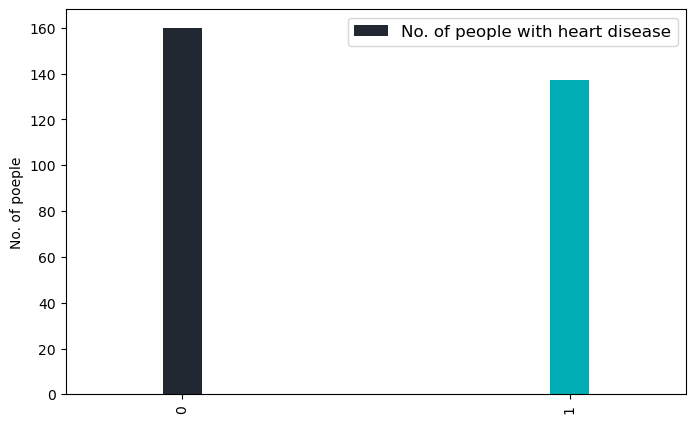

In [38]:
df.condition.value_counts().plot(kind="bar",width=0.1,color=["#222831","#00ADB5"],legend=1,figsize=(8,5))
plt.ylabel('No. of poeple')
plt.legend(["No. of people with heart disease"],fontsize=12);
plt.show()

### CORRELAION MATRIX HEATMAP

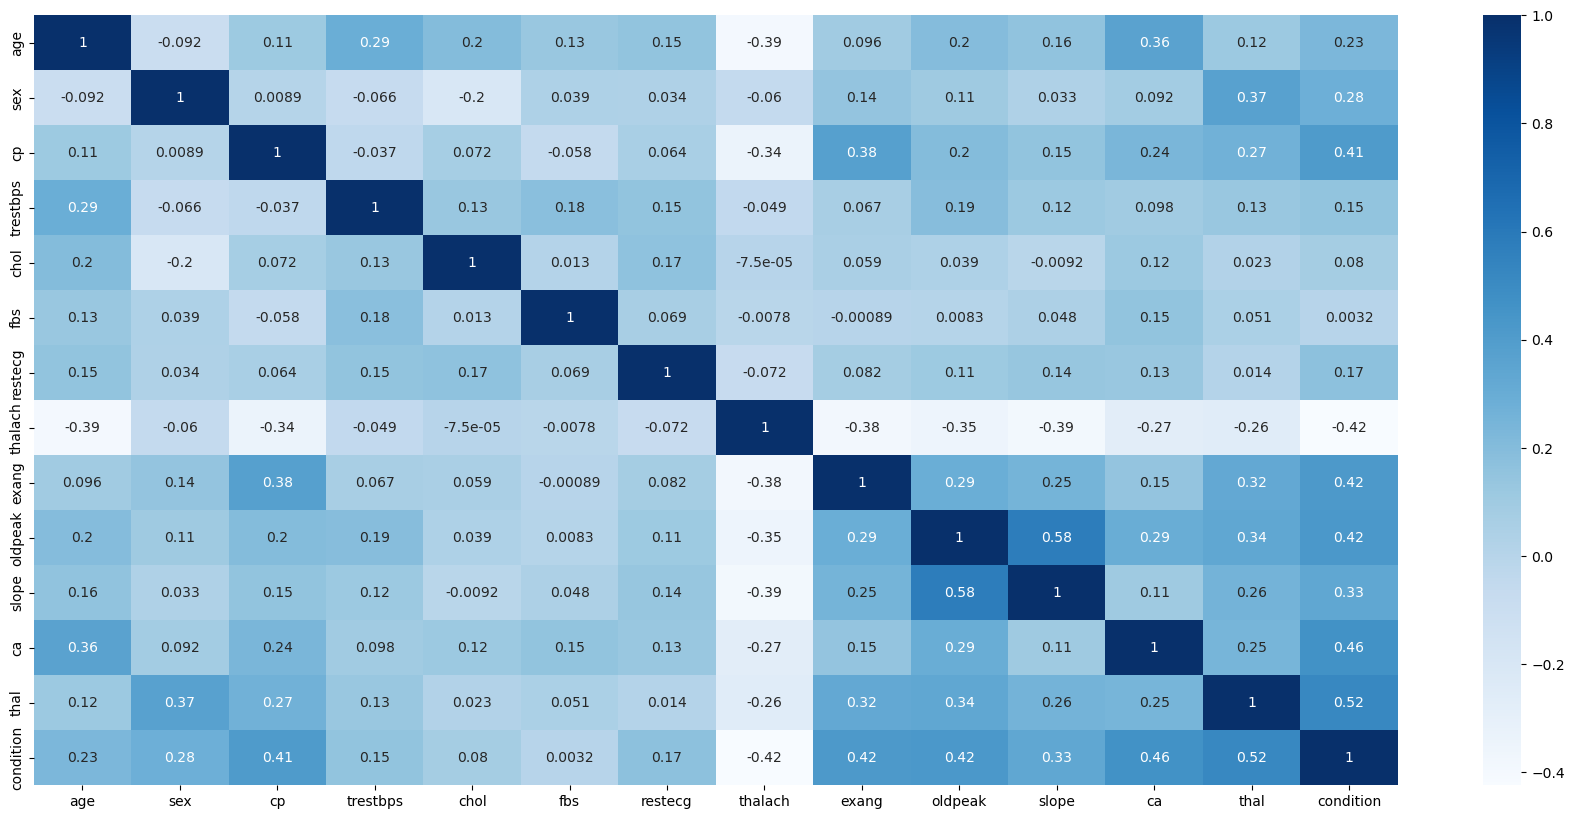

In [50]:
df.corr()
plt.figure(figsize = (22, 10))
sns.heatmap(df.corr(), annot = True,cmap="Blues")
plt.show()

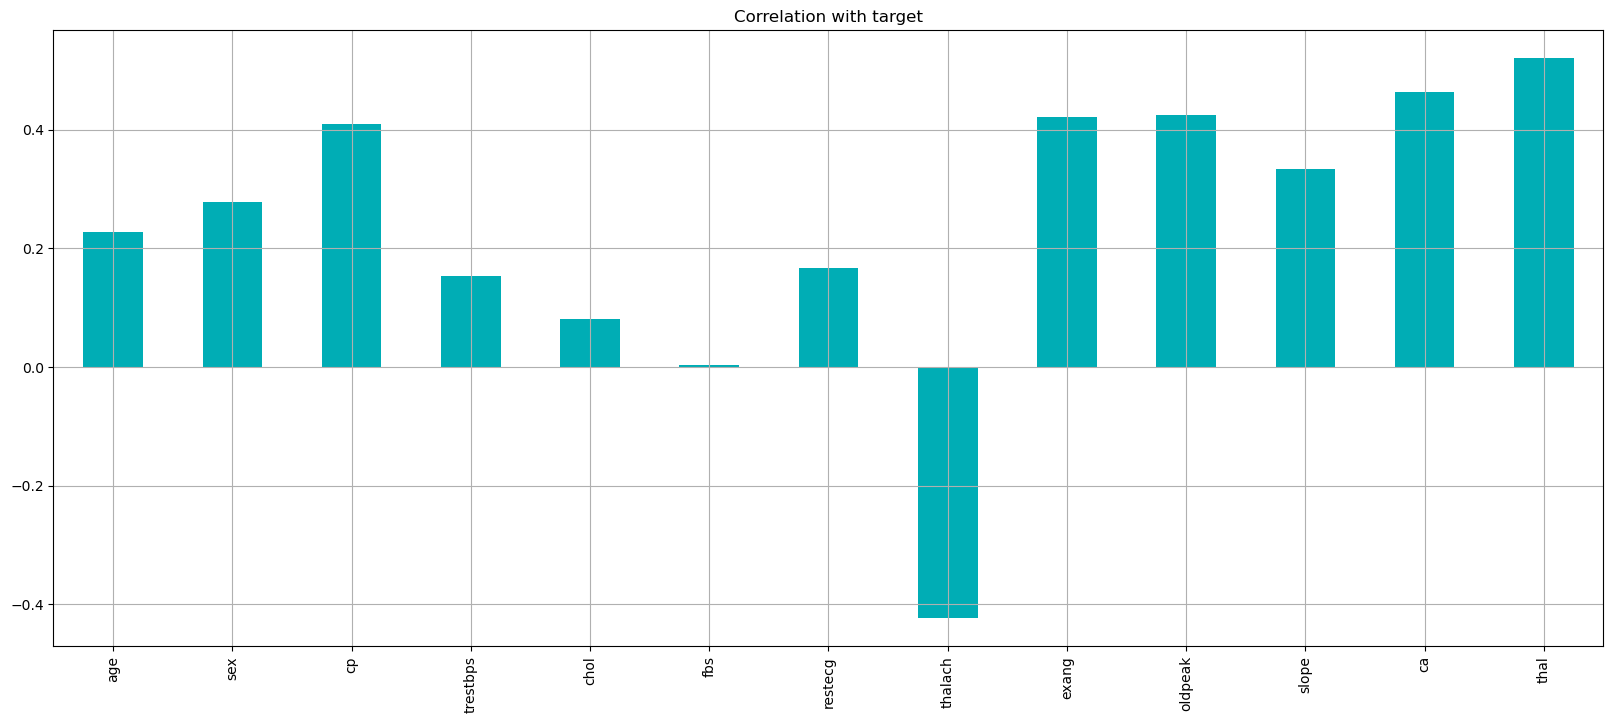

In [39]:
df.drop('condition', axis=1).corrwith(df.condition).plot(kind='bar',
                                                                 grid=True, figsize=(20, 8),
                                                                 title="Correlation with target",
                                                                 color="#00ADB5");


Observations from correlation:
-------------------------------------------------------------------------------
fbs and chol are the least correlated with the target variable.

All other variables have a significant correlation with the target variable.


In [10]:
categorical_val = []
continous_val = []
for column in df.columns:
    if len(df[column].unique()) <= 10:
        categorical_val.append(column)
    else:
        continous_val.append(column)

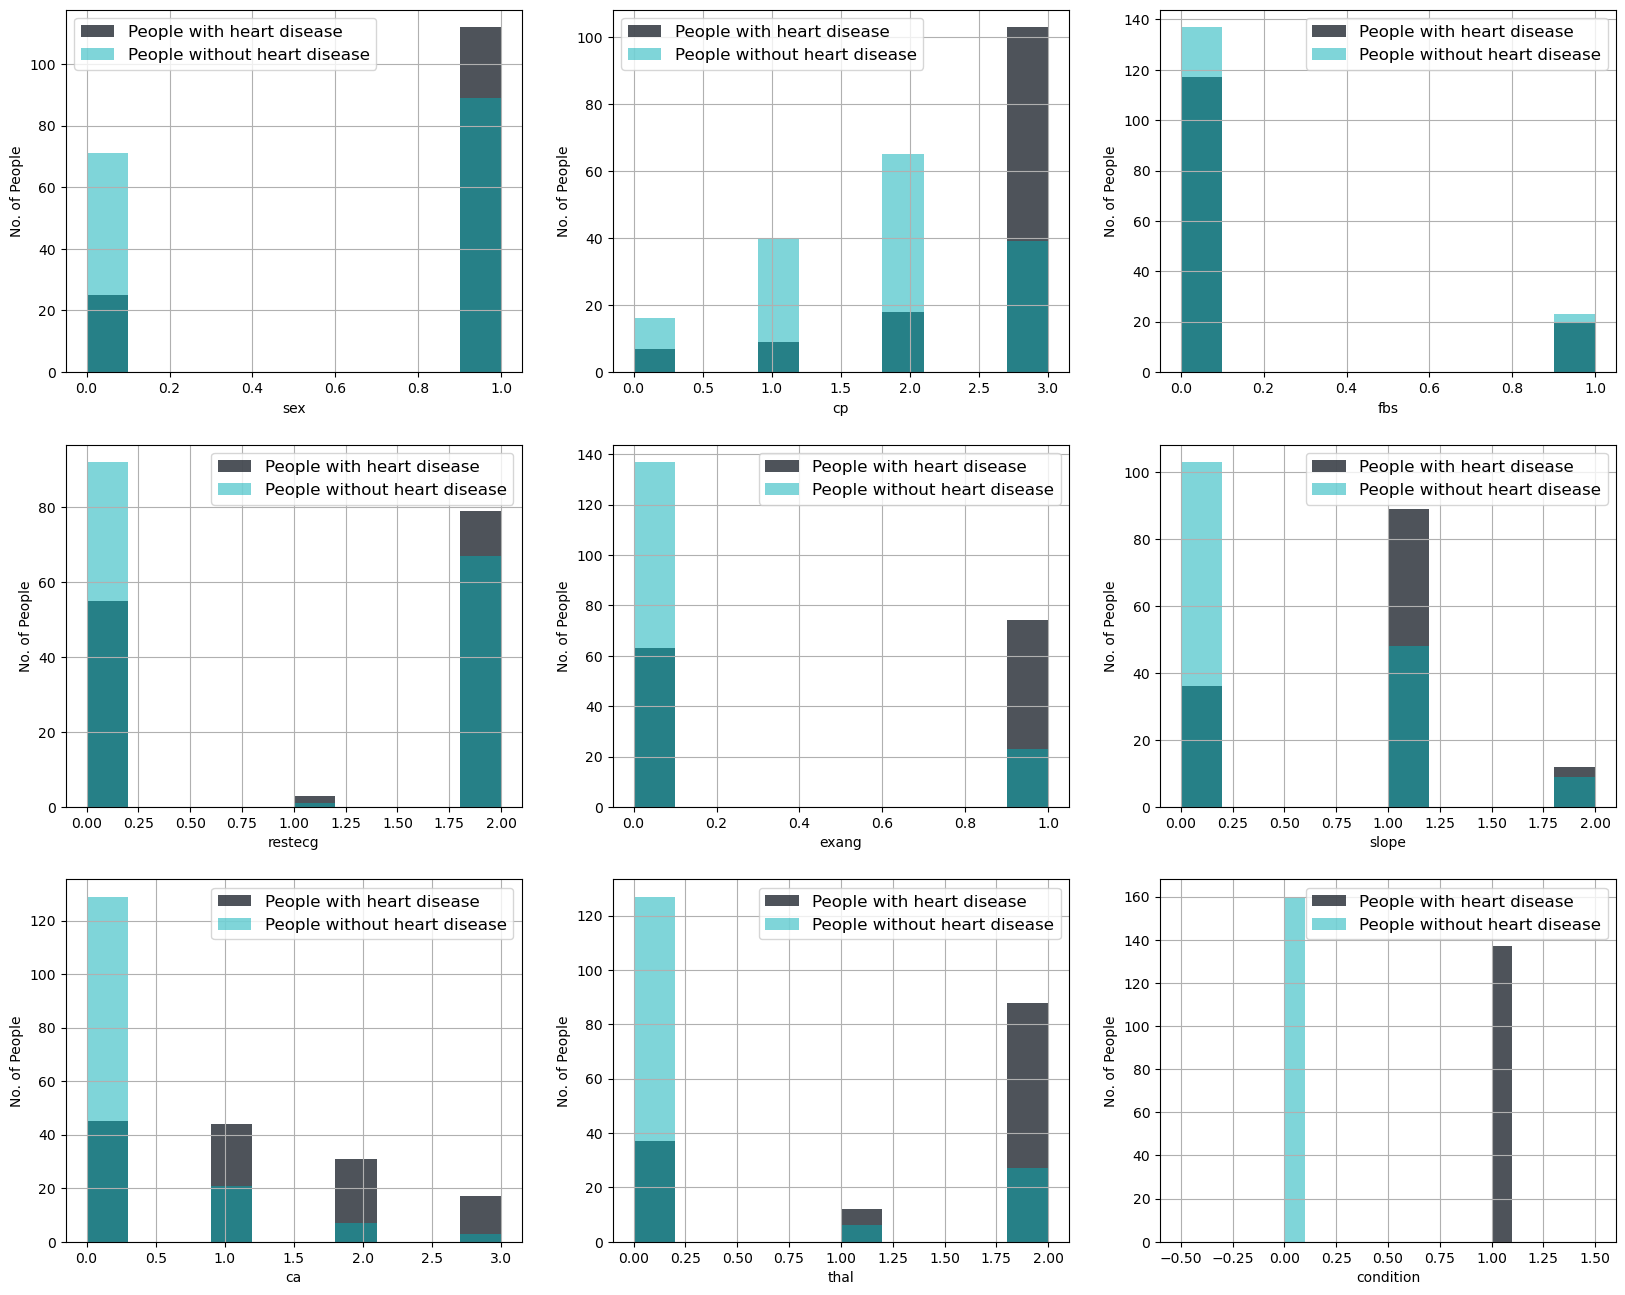

In [43]:
plt.figure(figsize=(20, 16))
for i, column in enumerate(categorical_val, 1):
    plt.subplot(3, 3, i)
    df[df["condition"] == 1][column].hist(bins=10, color='#222831', label='People with heart disease',alpha=0.8)
    df[df["condition"] == 0][column].hist(bins=10, color='#00ADB5', label='People without heart disease',alpha=0.5)
    plt.legend(fontsize=12)
    plt.xlabel(column)
    plt.ylabel("No. of People")

Observations from the above plot:
. cp {Chest pain}: People with cp 1, 2, 3 are more likely to have heart disease than people with cp 0.

. restecg {resting EKG results}: People with a value of 1 (reporting an abnormal heart rhythm, which can range from mild symptoms to severe problems) are more likely to have heart disease.

. exang {exercise-induced angina}: People with a value of 0 (No - angina induced by exercise) have more heart disease than people with a value of 1 (Yes - angina induced by exercise)

. slope {the slope of the ST segment of peak exercise}: People with a slope value of 2 (Downslopins: signs of an unhealthy heart) are more likely to have heart disease than people with a slope value of 2 slope is 0 (Upsloping: best heart rate with exercise) or 1 (Flatsloping: minimal change (typical healthy heart)).

. ca {number of major vessels (0-3) stained by fluoroscopy}: The more blood movement the better, so people with ca equal to 0 are more likely to have heart disease.

. thal {thalium stress result}: People with a thal value of 2 (defect corrected: once was a defect but ok now) are more likely to have heart disease.



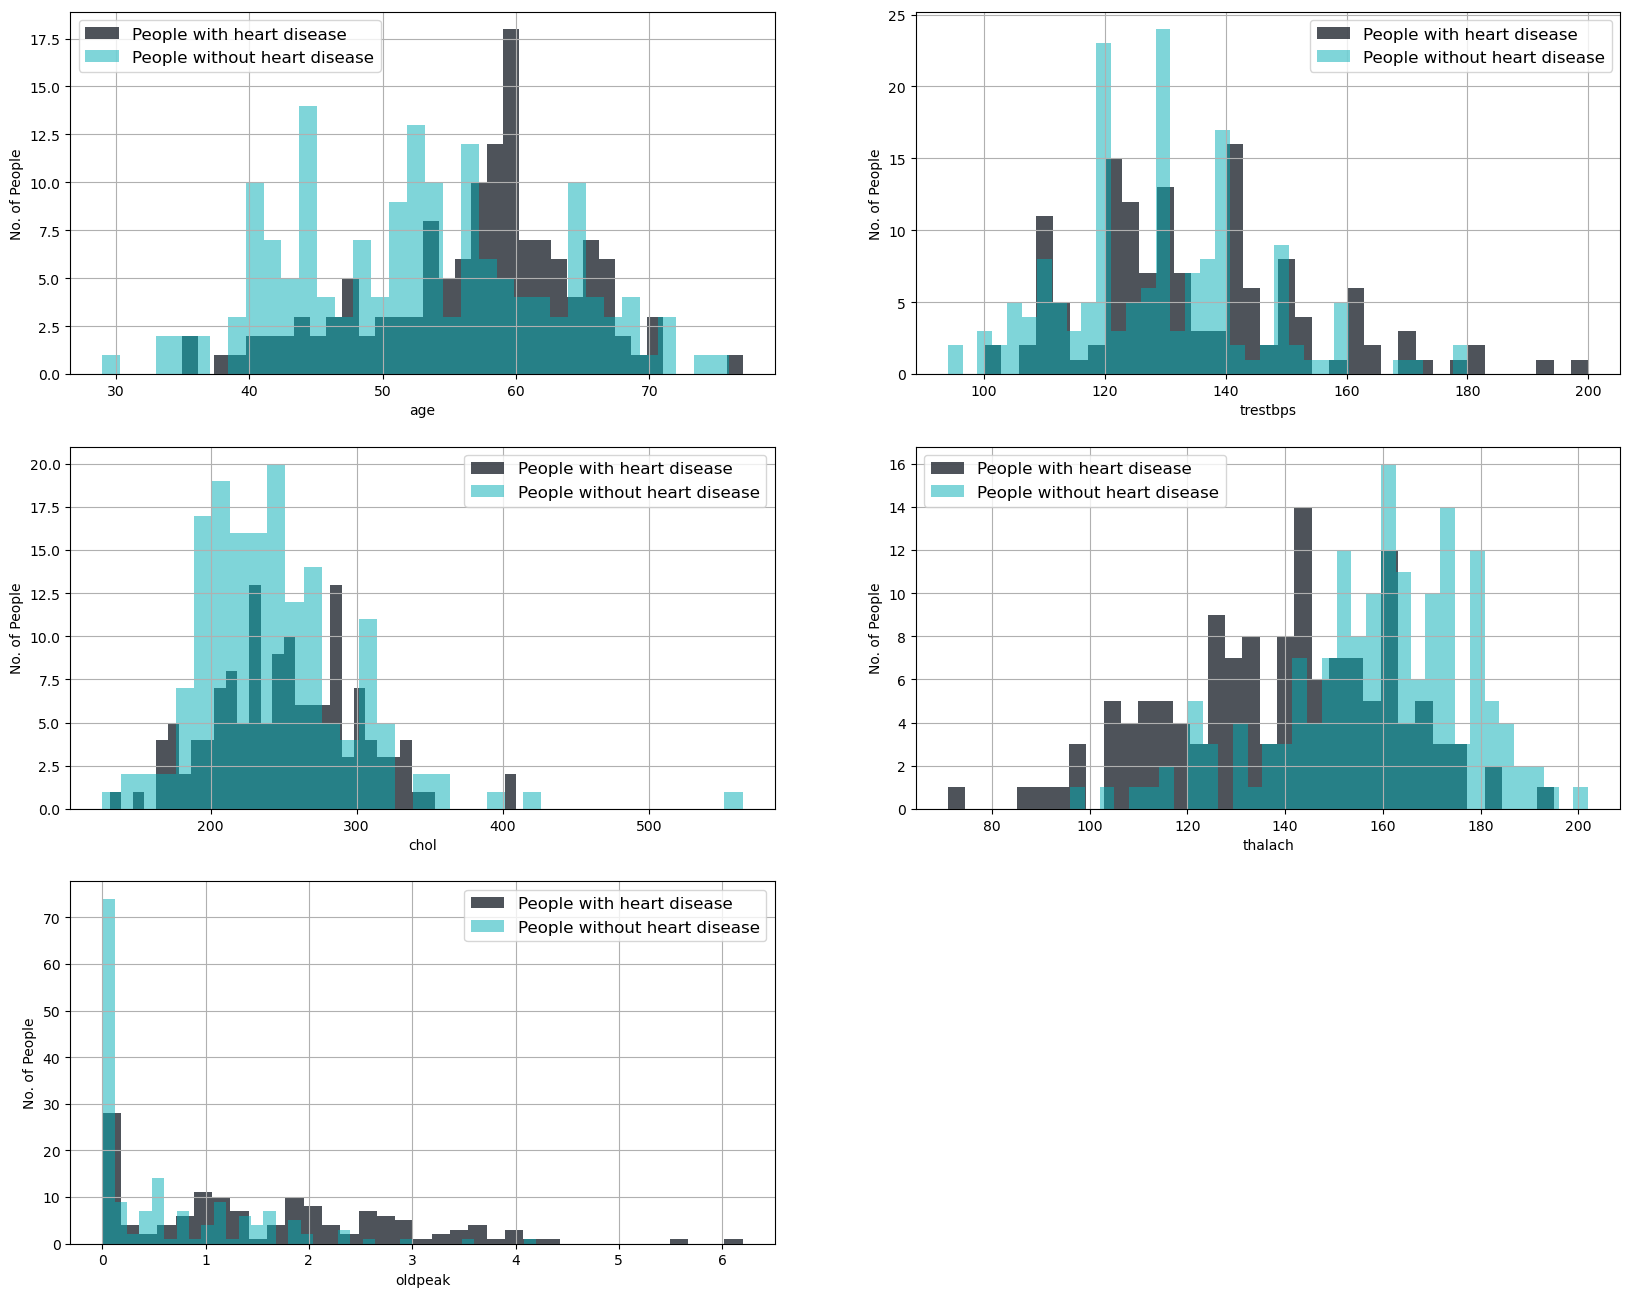

In [34]:
plt.figure(figsize=(20, 16))
for i, column in enumerate(continous_val, 1):
    plt.subplot(3, 2, i)
    df[df["condition"] == 1][column].hist(bins=35, color='#222831', label='People with heart disease', alpha=0.8)
    df[df["condition"] == 0][column].hist(bins=35, color='#00ADB5', label='People without heart disease',alpha=0.5)
    plt.legend(fontsize=12)
    plt.xlabel(column)
    plt.ylabel("No. of People")

Observations from the above plot:

. trestbps: resting blood pressure anything above 120-140 is generally of concern.

. chol: greater than 200 is of concern.

. thalach: People with a maximum heart rate of over 140 are more likely to have heart disease.

. the old peak of exercise-induced ST depression vs. rest looks at heart stress during exercise an unhealthy heart will stress more.


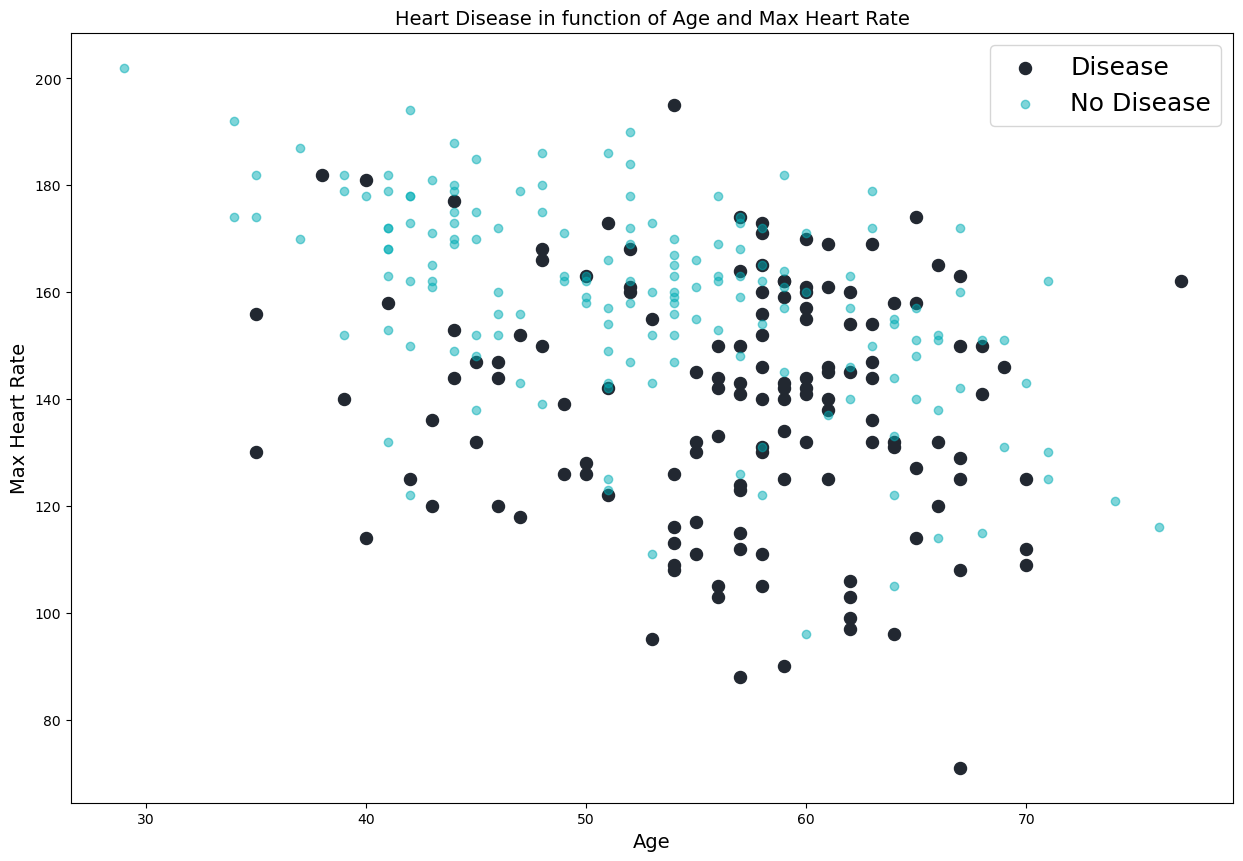

In [42]:
plt.figure(figsize=(15, 10))
plt.scatter(df.age[df.condition==1],df.thalach[df.condition==1],c="#222831",s=75)
plt.scatter(df.age[df.condition==0],df.thalach[df.condition==0],c="#00ADB5",alpha=0.5)
plt.title("Heart Disease in function of Age and Max Heart Rate",fontsize=14)
plt.xlabel("Age", fontsize=14)
plt.ylabel("Max Heart Rate", fontsize=14)
plt.legend(["Disease", "No Disease"],fontsize=18);

Observation from above plot:

This data isn't correlated at all so it is of no use to us.

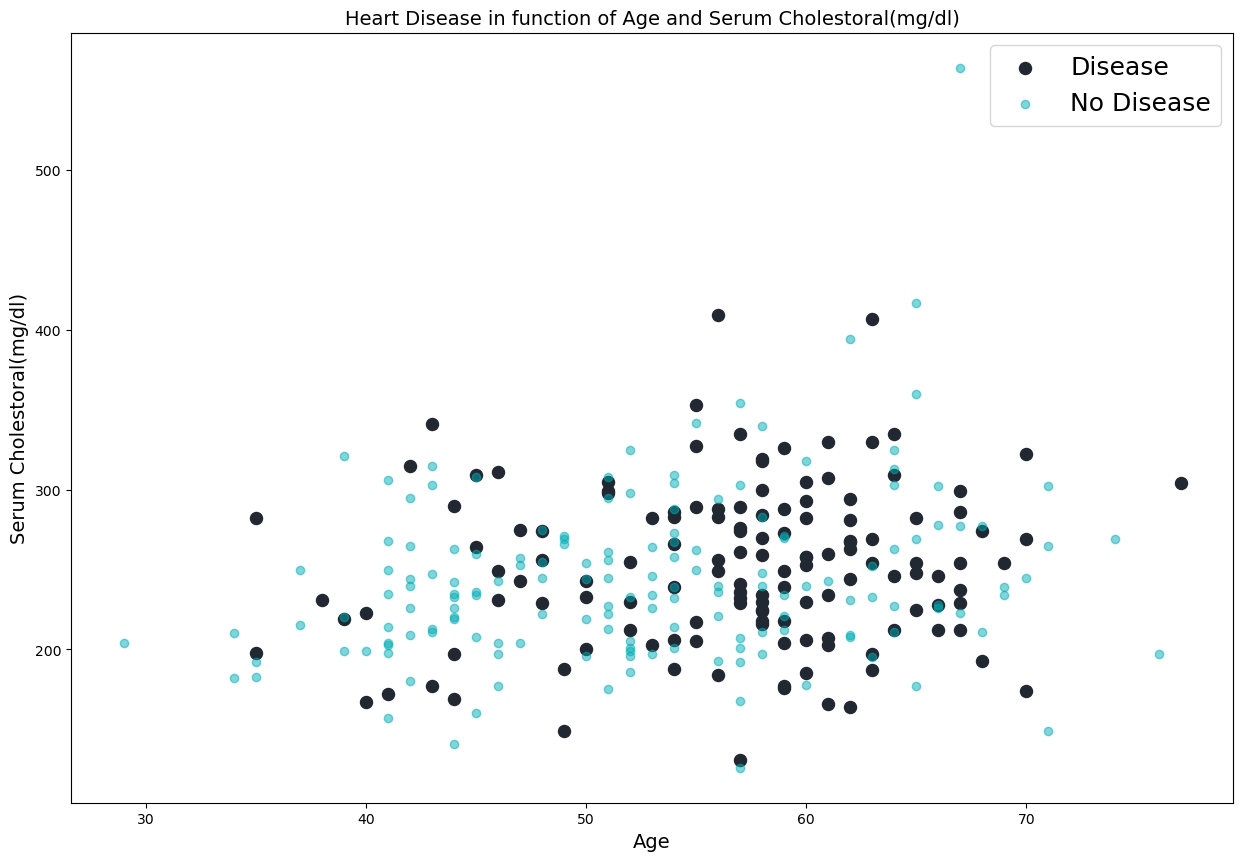

In [41]:
plt.figure(figsize=(15, 10))
plt.scatter(df.age[df.condition==1],df.chol[df.condition==1],c="#222831",s=75)
plt.scatter(df.age[df.condition==0],df.chol[df.condition==0],c="#00ADB5",alpha=0.5)
plt.title("Heart Disease in function of Age and Serum Cholestoral(mg/dl)",fontsize=14)
plt.xlabel("Age", fontsize=14)
plt.ylabel("Serum Cholestoral(mg/dl)", fontsize=14)
plt.legend(["Disease", "No Disease"],fontsize=18);

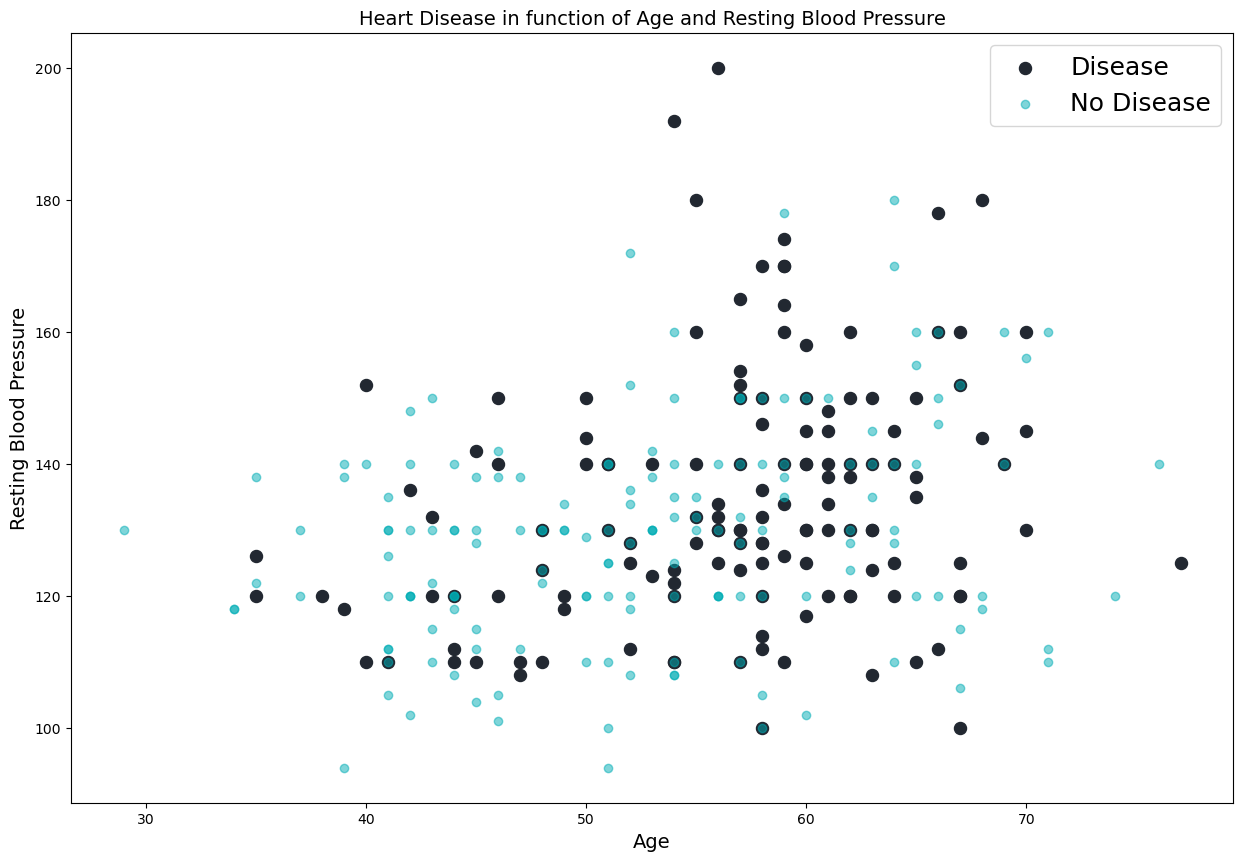

In [40]:
plt.figure(figsize=(15, 10))
plt.scatter(df.age[df.condition==1],df.trestbps[df.condition==1],c="#222831",s=75)
plt.scatter(df.age[df.condition==0],df.trestbps[df.condition==0],c="#00ADB5",alpha=0.5)
plt.title("Heart Disease in function of Age and Resting Blood Pressure",fontsize=14)
plt.xlabel("Age", fontsize=14)
plt.ylabel("Resting Blood Pressure", fontsize=14)
plt.legend(["Disease", "No Disease"],fontsize=18);

OBSERVATION from above plots(8 & 9):

. Both Resting Blood Pressure and Serum Cholesterol shows a bit positive correlation but not that much. Also, Resting Blood Pressure and Serum Cholesterol have few Outliers which we will remove in preprocessing steps.